### Ejercicio 2

Diseñe e implemente un algoritmo genético que busque el mejor subconjunto de características para la clasificación de cáncer (**leucemia linfocítica aguda (0)** y **leucemia mielógena aguda (1)**) a partir de datos genómicos.  

Se proveen **38 muestras** en el conjunto de entrenamiento y **34 en el conjunto de prueba** (`leukemia_train.csv` y `leukemia_test.csv`, respectivamente).  

Cada muestra se compone de un total de **7129 características**, que corresponden a valores de **expresión génica**.


Ahora lo que yo voy a querer encontrar es el cromosoma que me resuelva que subconjunto de genes utilizar para clasificar LLA y LMA

In [94]:
import numpy as np
import random
import time
from matplotlib import pyplot as plt
from sklearn import svm
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report



In [83]:
# Cargar los datos de entrenamiento
data_set = np.loadtxt('./data/leukemia_train.csv', delimiter=',')
dataset_tst = np.loadtxt('./data/leukemia_test.csv', delimiter=',')
data = data_set[:, :-1].copy()
yd = data_set[:, -1].copy()

data_tst = dataset_tst[:, :-1].copy()
yd_tst = dataset_tst[:, -1].copy()

In [9]:
def competencia(poblacion, fitness, k=2): 
  # elegir k índices al azar
  indices = random.sample(range(len(poblacion)), k)
    
  # buscar el índice del que tenga mejor fitness
  ganador_local = max(indices, key=lambda i: fitness[i])
    
  return poblacion[ganador_local]

In [11]:
def cruza(padre1, padre2): 
  punto = random.randint(1, len(padre1)-1)

  hijo1 = padre1[:punto] + padre2[punto:]
  hijo2 = padre2[:punto] + padre1[punto:]

  return hijo1, hijo2

In [12]:
def mutacion(individuo, prob = 0.01): 
  # Incertamos una probabilidad de mutacion ya que no siempre mutamos
  # Por ejemplo con prob = 0.01 cada bit tiene un 1% de cambiar

  prob_i = np.random.rand()
  if prob_i < prob: 
    pos = np.random.choice(len(individuo))
    individuo_mutado = list(individuo)
    if(individuo_mutado[pos] == "0"): 
      individuo_mutado[pos] == "1"
    else: 
      individuo_mutado[pos] = "0"
    
    individuo = "".join(individuo_mutado)
  
  return individuo

In [ ]:
def elitismo(poblacion, fitness): 
  elite_index = sorted(range(len(fitness)), key=lambda i: fitness[i], reverse=True)[0]
  return poblacion[elite_index]

In [14]:
def inicializar_poblacion(pop_size, n_bits): 
  poblacion = []
  for _ in range(pop_size): 
    cromosoma = ""
    for _ in range(n_bits): 
      cromosoma += random.choice("01")
    poblacion.append(cromosoma)
  return poblacion

In [ ]:
def fitness_function(cromosoma, X, y, penalidad = 0.01):
  # X son los datos de mi problema
  # y es la verdadera etiqueta
  # penalidad es un factor de penalizacion por la cantidad de genes
   
  # 1. Decod. el cromosoma y seleccionamos los genes que vamos a utilizar para clasificarlos
  cromosoma_array = np.array(list(cromosoma), dtype=int)
  seleccionados = np.where(cromosoma_array == 1)[0]

  if len(seleccionados) == 0: 
    return 0
  
  # Seleccionamos las columnas con los indices que correspondes a los genes elegidos osea a los 1
  X_sub = X[:, seleccionados]
  
  # 2. Clasificador (SVM lineal en este ejemplo)
  clf = svm.SVC(kernel="linear")

  # 3. Como tenemos pocos datos usamos valizacion cruzada
  scores = cross_val_score(clf, X_sub, y, cv=5,
                             scoring=make_scorer(f1_score, average="macro"))

  f1 = scores.mean()

  # 4. Penalización por cantidad de genes
  penalizacion = penalidad * (len(seleccionados) / X.shape[1])

  
  return f1 - penalizacion

In [79]:
def algoritmo_genetico(fitness_func, pop_size,n_bits, generaciones = 100, max_estable=20): 
  inicio = time.time()
  # 1. Inicializar poblacion
  poblacion = inicializar_poblacion(pop_size, n_bits)

  # Variables de control
  cont_estabilidad = 0
  apt_max = 1e-6
  aptitudes_max = []
  
  # 2. Obtenemos la funcion de aptitud para cada individuo
  for gen in range(generaciones): 
    fitness = []
    for individuo in poblacion:
      f = fitness_func(individuo, data, yd)     # calcular el valor de la función objetivo
      fitness.append(f)
    
    # 3. Elegimos al mejor de la poblacion
    mejor = elitismo(poblacion, fitness)
  
    # 4. Inicializamos la nueva poblacion
    nueva_pob = []

    nueva_pob.append(mejor)

    while(len(nueva_pob) < len(poblacion)): 
      # 5. Realizamos la seleccion
      padre1 = competencia(poblacion, fitness)
      padre2 = competencia(poblacion, fitness)

      # 6. Cruza
      hijo1, hijo2 = cruza(padre1, padre2)

      # 7. Mutacion
      hijo1 = mutacion(hijo1)
      hijo2 = mutacion(hijo2)

      # 8. Lo agregamos a la nueva poblacion
      nueva_pob.append(hijo1)
      if len(nueva_pob) < len(poblacion):  # no pasarse del tamaño
        nueva_pob.append(hijo2)
      
    # 9. Evaluacion de estabilidad
    if np.isclose(max(fitness), apt_max):
      cont_estabilidad += 1
    else:
      cont_estabilidad = 0

    if cont_estabilidad >= max_estable:
      print(f"Se alcanzó estabilidad en la generación {gen}")
      break

    # Actualizar para la siguiente generación
    poblacion = nueva_pob
    aptitudes_max.append(max(fitness))
    apt_max = max(fitness)

  # Seleccionar mejor individuo final
  fitness = []
  for individuo in poblacion:
    f = fitness_func(individuo, data, yd)     # calcular el valor de la función objetivo
    fitness.append(f)
  
  mejor_idx = max(range(len(fitness)), key=lambda i: fitness[i])
  mejor_cromosoma = poblacion[mejor_idx]
  mejor_fit = fitness[mejor_idx]

  # Gráfico de evolución
  plt.plot(range(len(aptitudes_max)), aptitudes_max)
  plt.xlabel("Generación")
  plt.ylabel("Mejor fitness")
  plt.title(f"Evolución del AG con tamaño de poblacion {pop_size}")
  plt.show()
    
  fin = time.time()
  print(f'El algoritmo terminó en la generación {gen} en {round(fin-inicio,4)} segundos.')

  return mejor_cromosoma


Se alcanzó estabilidad en la generación 36


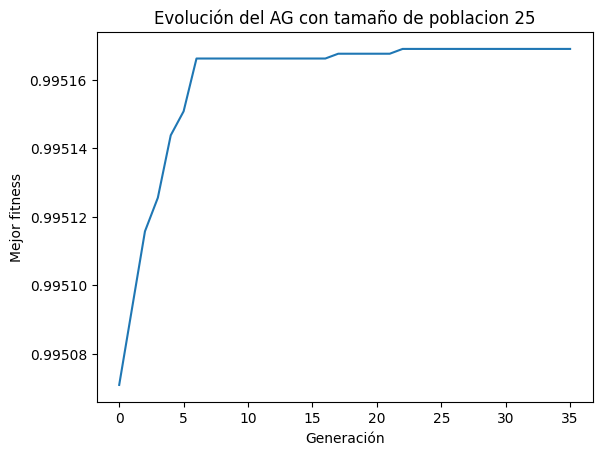

El algoritmo terminó en la generación 36 en 11.0707 segundos.


In [81]:
ganador = algoritmo_genetico(fitness_function, 25,data.shape[1], generaciones = 100, max_estable=30)


In [82]:
print(ganador)

1110000111110010111000010001100111100001001111001100101110100100110111100011101111011010000110111100011000101001000010000110011100000000001001011011000100100000110001010110110011011100101010111000110010110001101111011001100111000100100011101010001010100000011011100000101110110010011111001110000011111111110100000000001111010100100111100100011111001100011100011000101001010011110100110000010001000110101010111101001100000010100001001101101001011000111011100110011000111010010111010101110001011000001110110011000011001110000001000101000100000111110111000100000100111011110110101100010100111111110100001001010110000100100110000100110000001100101011011010100100110111111001100010000001001101010011010100110111010110001101101010110110101010101110011100011001001101001111110111010110010100010110011000100011011001110110001000010110000001001110111001110111101100001011110011101011000100101101011111000001100111110111000001110000011000100100111110110110111010001000010101010011110011101011100000001000101010

## Entrenamos el modelo solamente utilizando los genes elegidos

In [102]:
ganador_array = np.array(list(ganador), dtype=int)
seleccionados = np.where(ganador_array == 1)[0]

 # Seleccionamos las columnas con los indices que correspondes a los genes elegidos osea a los 1
X_sub = data[:, seleccionados]
  
# 2. Clasificador (SVM lineal en este ejemplo)
clf = svm.SVC(kernel="linear")

clf.fit(X_sub, yd)

SVC(kernel='linear')

## Evaluamos el modelo con los datos de prueba

In [97]:

X_sub = data_tst[:, seleccionados]
y_pred = clf.predict(X_sub)

print("Accuracy:", accuracy_score(yd_tst, y_pred))
print("F1:", f1_score(yd_tst, y_pred, average="macro"))
print(classification_report(yd_tst, y_pred))

Accuracy: 0.9705882352941176
F1: 0.9692863595302619
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98        20
         1.0       1.00      0.93      0.96        14

    accuracy                           0.97        34
   macro avg       0.98      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34

